# LeetCode #1074: Number of Submatrices That Sum to Target

https://leetcode.com/problems/number-of-submatrices-that-sum-to-target/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(m^2 \cdot n^2)$ | $O(m \cdot n)$ |
| **2D Prefix Sum + Hash Map** ★ | $O(m^2 \cdot n)$ | $O(m \cdot n)$ |

---

## Understanding the Methods

### Brute Force
Fix all four corner indices $(r_1, r_2, c_1, c_2)$ to define a submatrix — $O(m^2 \cdot n^2)$ pairs — then look up each sum in $O(1)$ from a prebuilt 2D prefix table. Simple but iterates every possible submatrix.

### Optimal: 2D Prefix Sum + Hash Map ★
Fix two row boundaries $r_1$ and $r_2$ ($O(m^2)$ pairs), collapsing the 2D problem into a 1D column-sum array. A running frequency map (the subarray-sum-equals-$k$ trick) resolves each 1D pass in $O(n)$, giving $O(m^2 \cdot n)$ total.

**Why this is better than Brute Force:** Eliminates the $n^2$ column-pair loop by applying the hash-map subarray-sum technique along the column axis, cutting from $O(m^2 \cdot n^2)$ to $O(m^2 \cdot n)$.

**Constraints:**
* 1 ≤ m, n ≤ 100
* −1000 ≤ matrix[i][j] ≤ 1000
* −10⁸ ≤ target ≤ 10⁸

## Solutions

### C#

In [ ]:
public class Solution {
    public int NumSubmatrixSumTarget(int[][] matrix, int target) {
        int m = matrix.Length, n = matrix[0].Length, count = 0;

        for (int r1 = 0; r1 < m; r1++) {
            int[] colSum = new int[n];
            for (int r2 = r1; r2 < m; r2++) {
                // Extend column sums to include the new row r2
                for (int c = 0; c < n; c++) colSum[c] += matrix[r2][c];

                // Subarray-sum-equals-target on colSum via a running frequency map
                var freq = new Dictionary<int, int> { [0] = 1 };
                int running = 0;
                for (int c = 0; c < n; c++) {
                    running += colSum[c];
                    if (freq.TryGetValue(running - target, out int f)) count += f;
                    freq[running] = freq.GetValueOrDefault(running) + 1;
                }
            }
        }
        return count;
    }
}

### Python

In [ ]:
class Solution:
    def numSubmatrixSumTarget(self, matrix: List[List[int]], target: int) -> int:
        m, n = len(matrix), len(matrix[0])
        count = 0

        for r1 in range(m):
            col_sum = [0] * n
            for r2 in range(r1, m):
                # Extend column sums to include the new row r2
                for c in range(n):
                    col_sum[c] += matrix[r2][c]

                # Subarray-sum-equals-target on col_sum via a running frequency map
                freq = {0: 1}
                running = 0
                for c in range(n):
                    running += col_sum[c]
                    count += freq.get(running - target, 0)
                    freq[running] = freq.get(running, 0) + 1

        return count

### Go

In [ ]:
func numSubmatrixSumTarget(matrix [][]int, target int) int {
    m, n, count := len(matrix), len(matrix[0]), 0

    for r1 := 0; r1 < m; r1++ {
        colSum := make([]int, n)
        for r2 := r1; r2 < m; r2++ {
            // Extend column sums to include the new row r2
            for c := 0; c < n; c++ {
                colSum[c] += matrix[r2][c]
            }

            // Subarray-sum-equals-target on colSum via a running frequency map
            freq := map[int]int{0: 1}
            running := 0
            for c := 0; c < n; c++ {
                running += colSum[c]
                count += freq[running-target]
                freq[running]++
            }
        }
    }
    return count
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn num_submatrix_sum_target(matrix: Vec<Vec<i32>>, target: i32) -> i32 {
        let (m, n) = (matrix.len(), matrix[0].len());
        let mut count = 0i32;

        for r1 in 0..m {
            let mut col_sum = vec![0i32; n];
            for r2 in r1..m {
                // Extend column sums to include the new row r2
                for c in 0..n {
                    col_sum[c] += matrix[r2][c];
                }

                // Subarray-sum-equals-target on col_sum via a running frequency map
                let mut freq: HashMap<i32, i32> = HashMap::from([(0, 1)]);
                let mut running = 0i32;
                for c in 0..n {
                    running += col_sum[c];
                    count += freq.get(&(running - target)).copied().unwrap_or(0);
                    *freq.entry(running).or_insert(0) += 1;
                }
            }
        }
        count
    }
}

## Example Scenarios

**1. Common Case**
**Input:** matrix = [[1,−1],[−1,1]], target = 0
Both rows (1+−1=0, −1+1=0), both columns (1+−1=0, −1+1=0), and the full 2×2 matrix (1−1−1+1=0) each sum to 0. The four single cells don't (±1 ≠ 0). Output: **5**.

**2. Slightly Complex**
**Input:** matrix = [[0,1,0],[1,1,1],[0,1,0]], target = 0
All values are ≥ 0, so only submatrices consisting entirely of zero cells qualify. The four corner cells (mat[0][0], mat[0][2], mat[2][0], mat[2][2]) each equal 0; no contiguous multi-cell rectangular block isolates just zeros. Output: **4**.

**3. Edge Case: Time Factor — speedup at large dimensions**
**Input:** 100×100 matrix, arbitrary values, any target
Brute Force enumerates $100^2 \times 100^2 = 10^8$ submatrix pairs (each $O(1)$ with prefix sum). 2D Prefix Sum + Hash Map iterates $100^2$ row pairs × $100$ columns = $10^6$ steps — a $100\times$ speedup with no correctness trade-off.

**4. Edge Case: Space Factor — freq map stays bounded**
**Input:** matrix = [[0,0],[0,0]], target = 0
With all zeros, colSum is always $[0, 0]$ for every $(r_1, r_2)$ pair. The running sum stays 0 every column, so freq stays $\{0: k\}$ — a single key. In general the freq map holds at most $O(n)$ distinct running sums per pass, and colSum is always $O(n)$. Total extra space: $O(n)$ per pass, $O(m \cdot n)$ across all pairs.

**5. Almost-Impossible but Plausible — target is the matrix's total sum**
**Input:** matrix = [[−1,−1],[−1,−1]], target = −4
The only submatrix summing to −4 is the entire 2×2 matrix. For row pair (0,1), colSum = [−2, −2]. Running sums: after col 0 → −2; freq has no key at −2 − (−4) = 2. After col 1 → −4; freq[−4 − (−4)] = freq[0] = 1 → count = 1. Output: **1**.

## Infographic

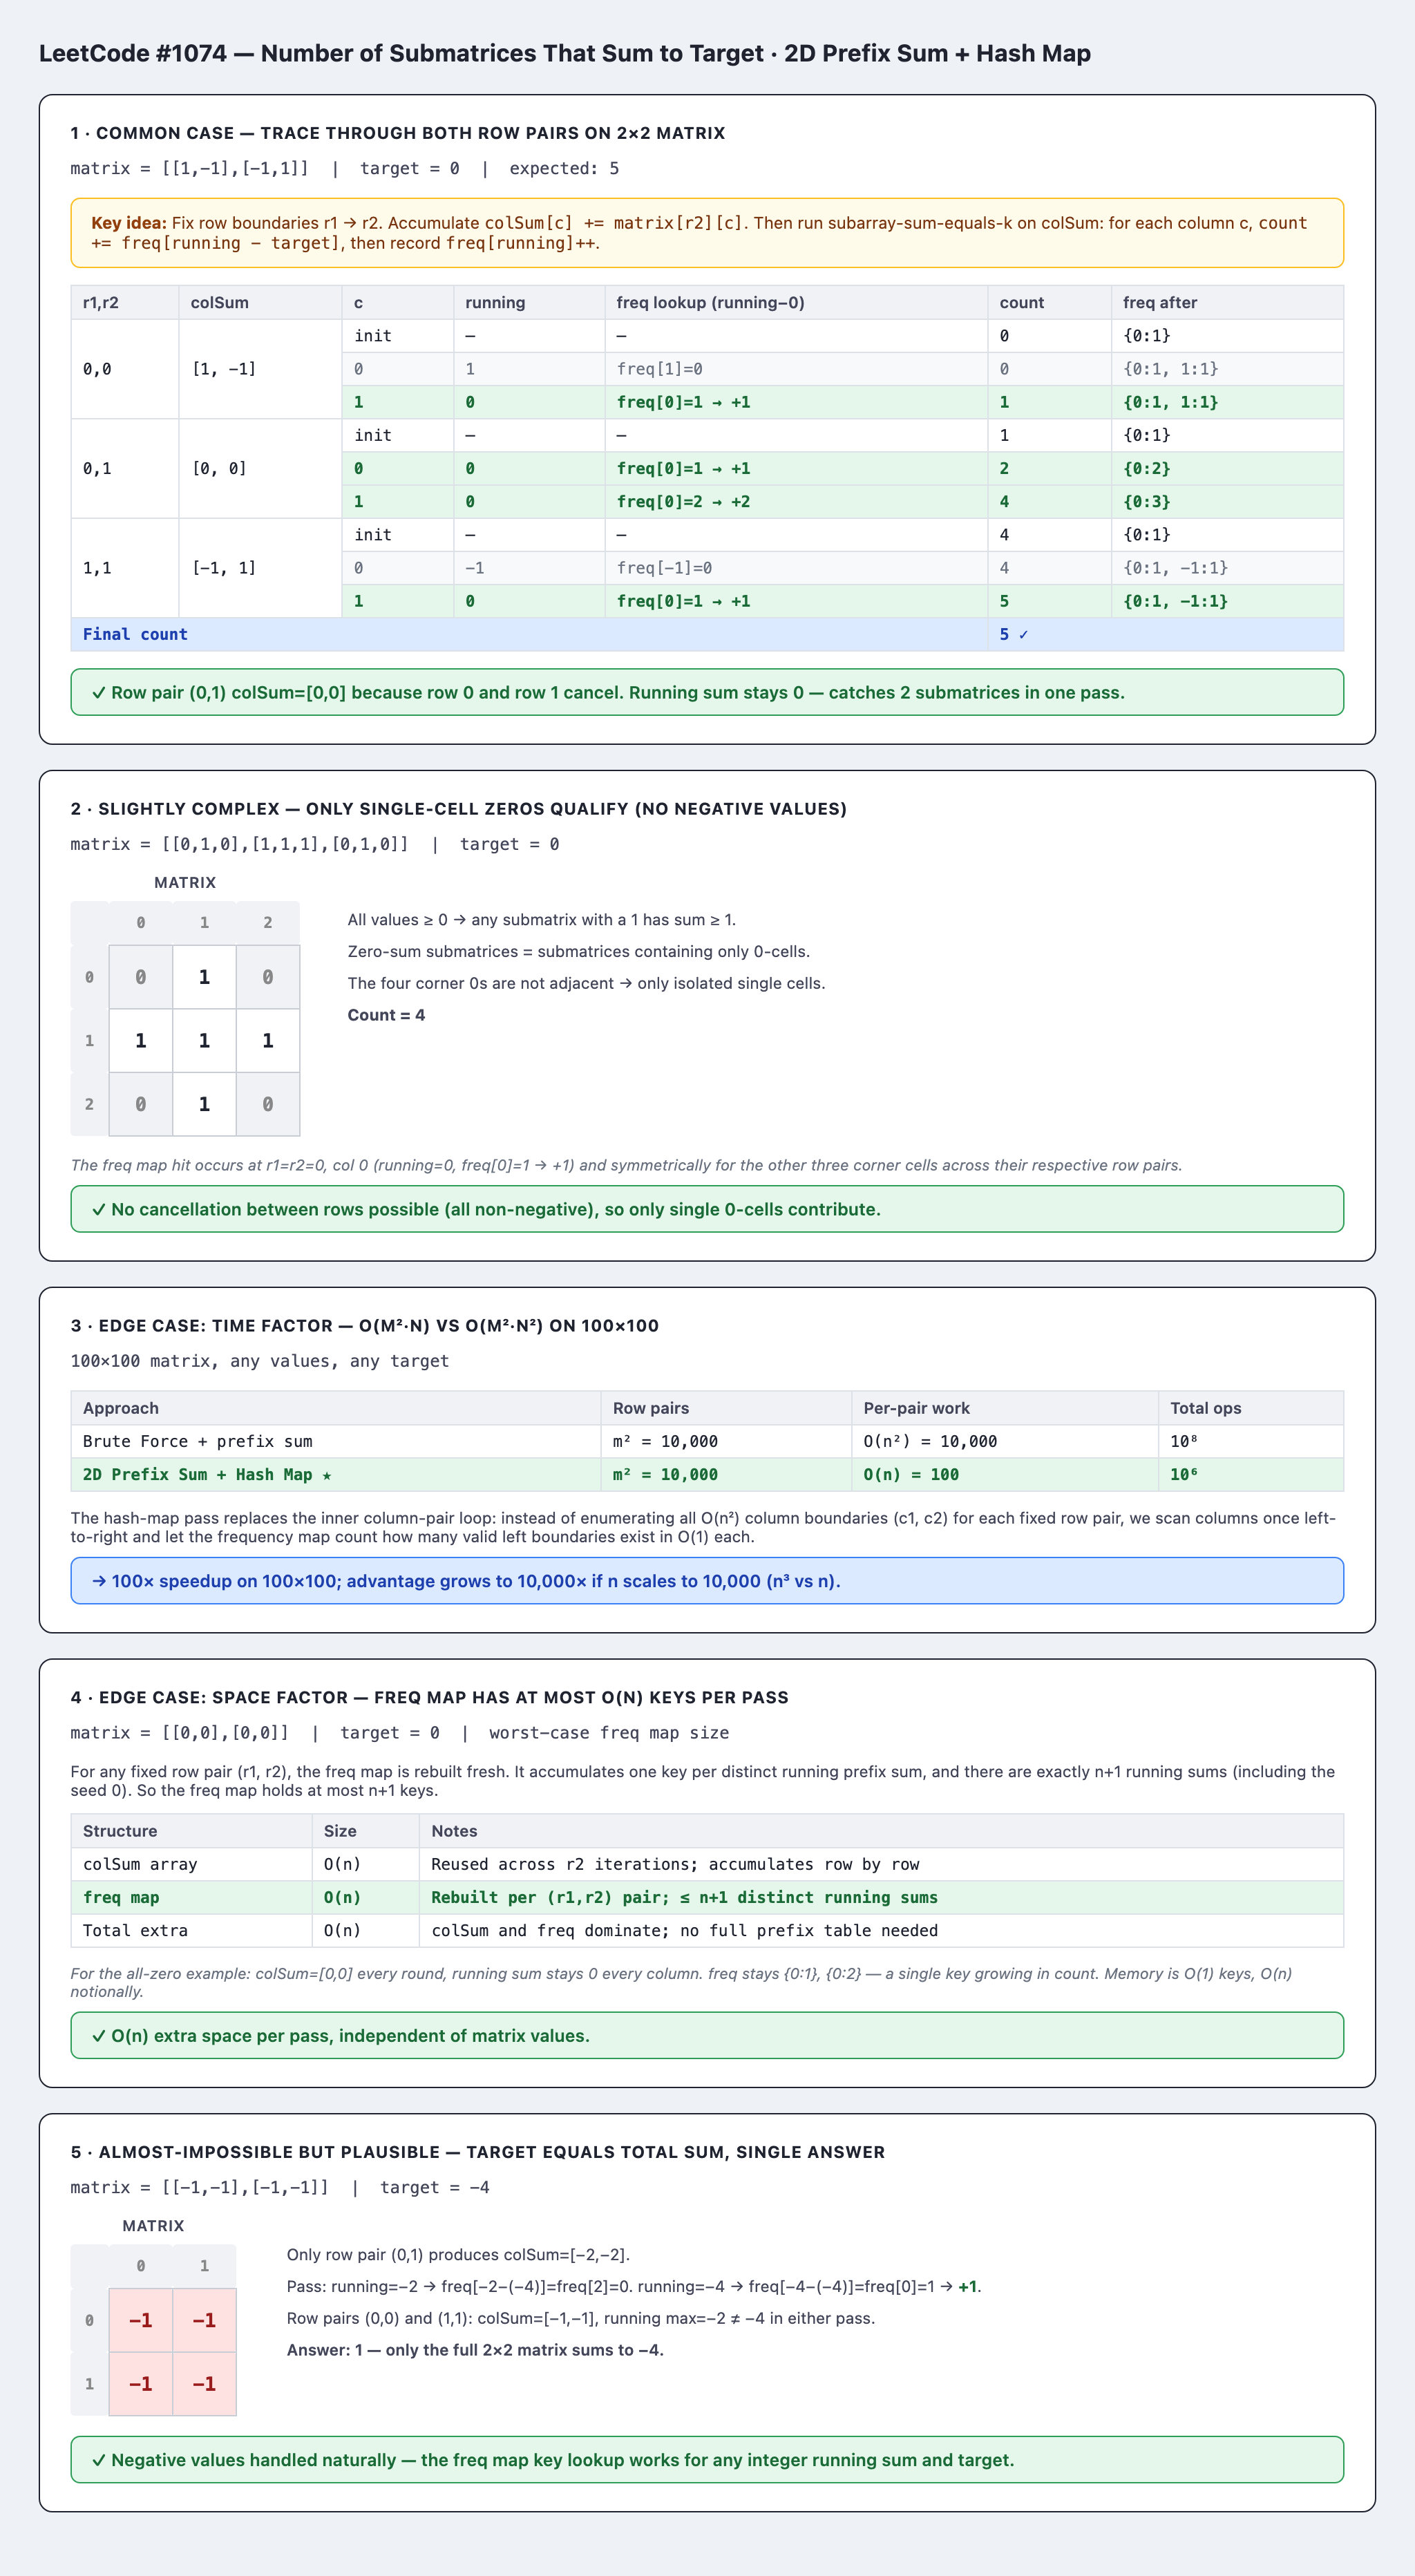